# Dataset_AGGREGATION

> **Project Phase**: Phase 4: Dataset Aggregation (14 Feb – 20 Feb 2026)

### Notebook Overview
- **Purpose**: Aggregate and merge six relational source tables into a unified resume dataset.
- **Input Data**: `Raw tables in Datasets/ and supplementary records in Dataset_add/`
- **Key Processing**: Relational joins on person_id, text field concatenation (skills, education, experience, abilities), target role derivation.
- **Primary Output**: `Dataset_add/aggregated_resume_dataset.csv, Dataset_add/enriched_resume_dataset.csv, Dataset_add/balanced_resume_dataset.csv, final_semantic_resume_dataset.csv`

---


Clean Data and Aggregate the Data

LOADING CLEANED DATASETS...

DATASET SHAPES
People Dataset      : (51378, 3)
Abilities Dataset   : (1180092, 2)
Education Dataset   : (68187, 7)
Experience Dataset  : (255867, 9)
Skills Dataset      : (1860156, 2)

MISSING VALUE ANALYSIS

People Dataset Missing Values:
person_id            0
profile_title        0
standardized_role    0
dtype: int64

Abilities Dataset Missing Values:
person_id    0
ability      0
dtype: int64

Education Dataset Missing Values:
person_id                   0
institution               222
program                     0
start_date              16974
location                18846
standardized_program        0
education_year          43209
dtype: int64

Experience Dataset Missing Values:
person_id                 0
title                     0
firm                   3915
start_date             2085
end_date               2505
location              50541
standardized_role         0
start_year            78306
end_year             109965
dtype: int64

Skills Dat

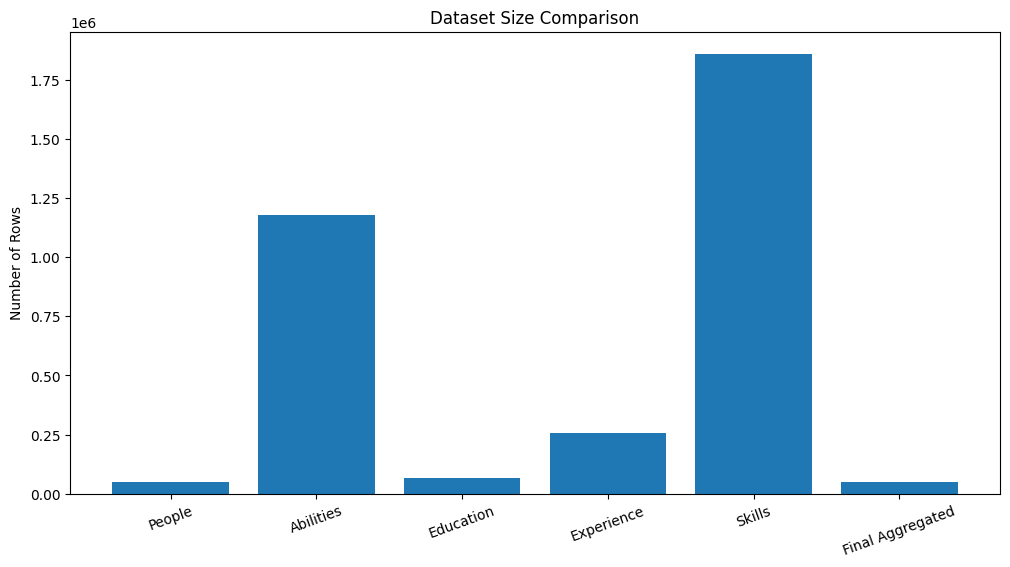

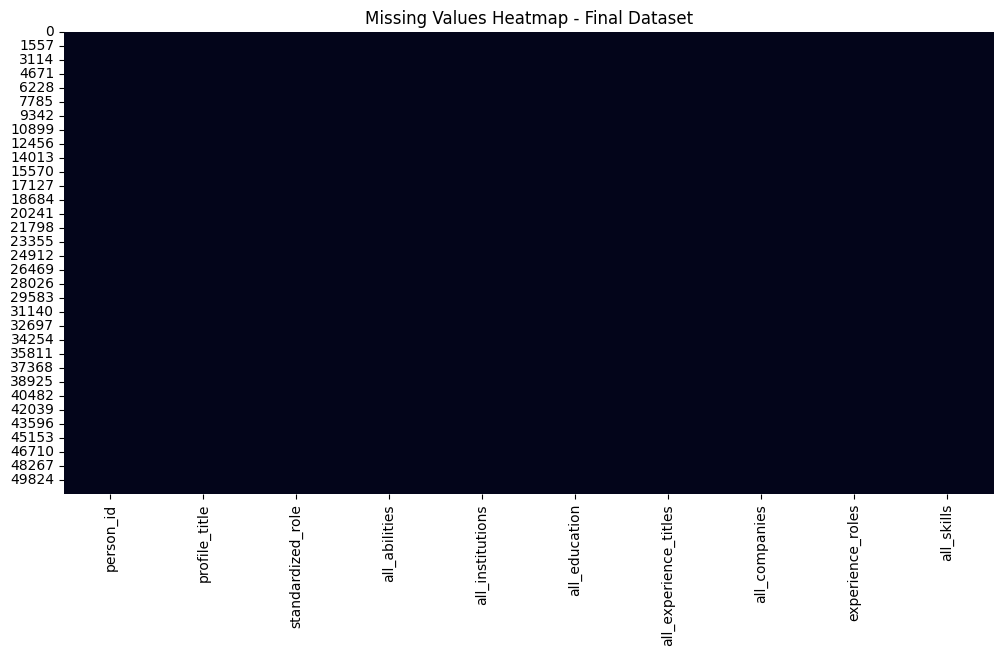

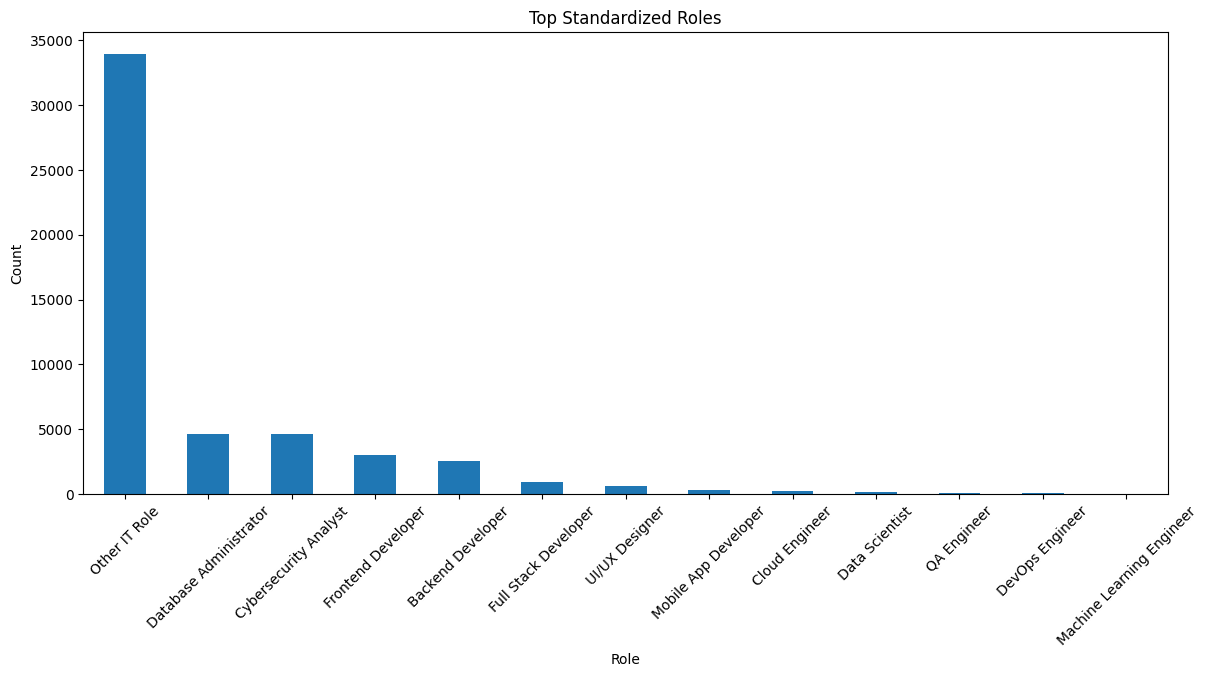

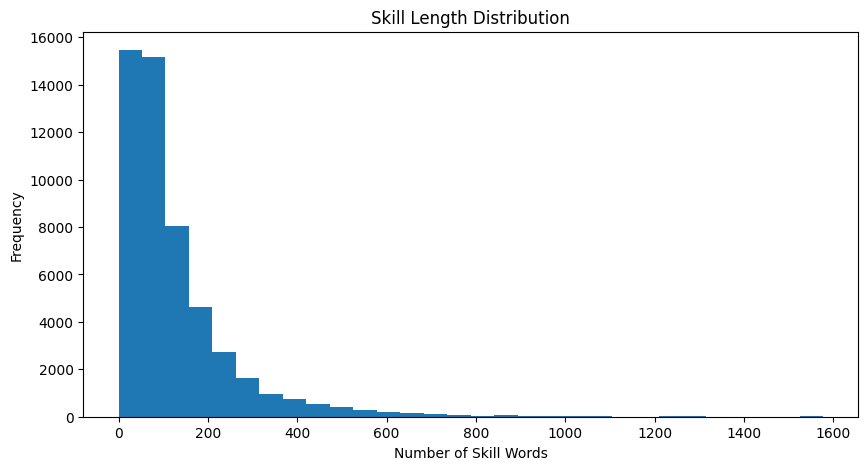

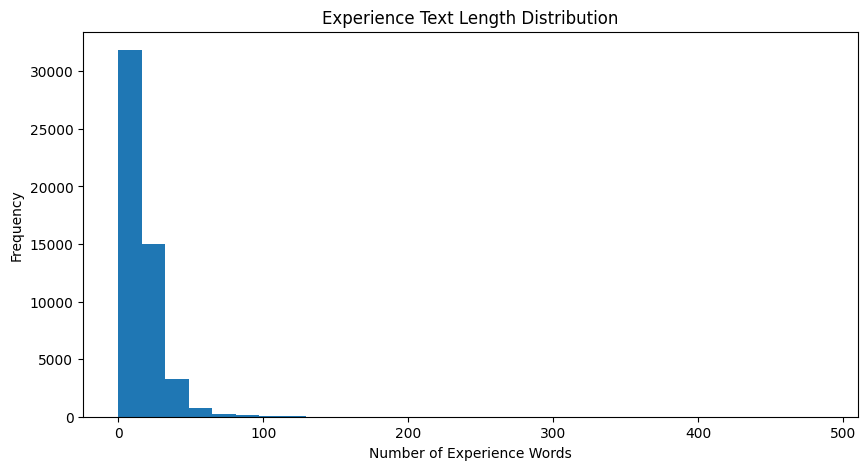


PROCESS COMPLETED SUCCESSFULLY

COMPLETED PHASES:

1. Loaded All Cleaned Datasets
2. Performed Final Cleaning
3. Aggregated All Information By person_id
4. Merged All Datasets
5. Generated Final Aggregated Dataset
6. Generated Dataset Statistics
7. Generated Visualization Plots

FINAL DATASET STRUCTURE:

person_id
profile_title
standardized_role
all_abilities
all_institutions
all_education
all_experience_titles
all_companies
experience_roles
all_skills

OUTPUT FILE:
aggregated_resume_dataset.csv

NEXT PHASE:
ROLE DETECTION + SEMANTIC ENRICHMENT



In [1]:
# ============================================================
# NLP PROJECT
# CLEAN + AGGREGATE ALL DATASETS
# ============================================================

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ============================================================
# DATASET PATHS
# ============================================================

base_path = "/content/drive/MyDrive/NLP_Project-2/Dataset_add"

people_path = f"{base_path}/01_people_add.csv"
abilities_path = f"{base_path}/02_abilities_add.csv"
education_path = f"{base_path}/03_education_add.csv"
experience_path = f"{base_path}/04_experience_add.csv"
skills_path = f"{base_path}/05_person_skills_add.csv"

# ============================================================
# OUTPUT PATH
# ============================================================

output_path = f"{base_path}/aggregated_resume_dataset.csv"

# ============================================================
# LOAD DATASETS
# ============================================================

print("=" * 80)
print("LOADING CLEANED DATASETS...")
print("=" * 80)

people_df = pd.read_csv(people_path)
abilities_df = pd.read_csv(abilities_path)
education_df = pd.read_csv(education_path)
experience_df = pd.read_csv(experience_path)
skills_df = pd.read_csv(skills_path)

# ============================================================
# DATASET SHAPES
# ============================================================

print("\nDATASET SHAPES")
print("=" * 80)

print(f"People Dataset      : {people_df.shape}")
print(f"Abilities Dataset   : {abilities_df.shape}")
print(f"Education Dataset   : {education_df.shape}")
print(f"Experience Dataset  : {experience_df.shape}")
print(f"Skills Dataset      : {skills_df.shape}")

# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

print("\nMISSING VALUE ANALYSIS")
print("=" * 80)

datasets = {
    "People": people_df,
    "Abilities": abilities_df,
    "Education": education_df,
    "Experience": experience_df,
    "Skills": skills_df
}

for name, df in datasets.items():

    print(f"\n{name} Dataset Missing Values:")
    print(df.isnull().sum())

# ============================================================
# CLEANING SMALL REMAINING ISSUES
# ============================================================

print("\n" + "=" * 80)
print("FINAL CLEANING BEFORE AGGREGATION")
print("=" * 80)

# ------------------------------------------------------------
# PEOPLE
# ------------------------------------------------------------

people_df.drop_duplicates(inplace=True)

# ------------------------------------------------------------
# ABILITIES
# ------------------------------------------------------------

abilities_df.drop_duplicates(inplace=True)

abilities_df = abilities_df[
    abilities_df['ability'].notnull()
]

# ------------------------------------------------------------
# EDUCATION
# ------------------------------------------------------------

education_df.drop_duplicates(inplace=True)

education_df = education_df[
    education_df['standardized_program'].notnull()
]

# ------------------------------------------------------------
# EXPERIENCE
# ------------------------------------------------------------

experience_df.drop_duplicates(inplace=True)

experience_df = experience_df[
    experience_df['title'].notnull()
]

# ------------------------------------------------------------
# SKILLS
# ------------------------------------------------------------

skills_df.drop_duplicates(inplace=True)

skills_df = skills_df[
    skills_df['skill'].notnull()
]

# ============================================================
# AFTER CLEANING SHAPES
# ============================================================

print("\nAFTER FINAL CLEANING")
print("=" * 80)

print(f"People Dataset      : {people_df.shape}")
print(f"Abilities Dataset   : {abilities_df.shape}")
print(f"Education Dataset   : {education_df.shape}")
print(f"Experience Dataset  : {experience_df.shape}")
print(f"Skills Dataset      : {skills_df.shape}")

# ============================================================
# AGGREGATION FUNCTIONS
# ============================================================

print("\n" + "=" * 80)
print("STARTING AGGREGATION")
print("=" * 80)

def aggregate_text(series):

    unique_values = list(
        set(
            str(x).strip()
            for x in series
            if pd.notnull(x)
        )
    )

    return " | ".join(unique_values)

# ============================================================
# 1. AGGREGATE PEOPLE DATASET
# ============================================================

print("\nAggregating People Dataset...")

people_agg = people_df.groupby('person_id').agg({

    'profile_title': aggregate_text,
    'standardized_role': aggregate_text

}).reset_index()

print("People Aggregated Shape:", people_agg.shape)

# ============================================================
# 2. AGGREGATE ABILITIES DATASET
# ============================================================

print("\nAggregating Abilities Dataset...")

abilities_agg = abilities_df.groupby('person_id').agg({

    'ability': aggregate_text

}).reset_index()

abilities_agg.rename(columns={

    'ability': 'all_abilities'

}, inplace=True)

print("Abilities Aggregated Shape:", abilities_agg.shape)

# ============================================================
# 3. AGGREGATE EDUCATION DATASET
# ============================================================

print("\nAggregating Education Dataset...")

education_agg = education_df.groupby('person_id').agg({

    'institution': aggregate_text,
    'standardized_program': aggregate_text

}).reset_index()

education_agg.rename(columns={

    'institution': 'all_institutions',
    'standardized_program': 'all_education'

}, inplace=True)

print("Education Aggregated Shape:", education_agg.shape)

# ============================================================
# 4. AGGREGATE EXPERIENCE DATASET
# ============================================================

print("\nAggregating Experience Dataset...")

experience_agg = experience_df.groupby('person_id').agg({

    'title': aggregate_text,
    'firm': aggregate_text,
    'standardized_role': aggregate_text

}).reset_index()

experience_agg.rename(columns={

    'title': 'all_experience_titles',
    'firm': 'all_companies',
    'standardized_role': 'experience_roles'

}, inplace=True)

print("Experience Aggregated Shape:", experience_agg.shape)

# ============================================================
# 5. AGGREGATE SKILLS DATASET
# ============================================================

print("\nAggregating Skills Dataset...")

skills_agg = skills_df.groupby('person_id').agg({

    'skill': aggregate_text

}).reset_index()

skills_agg.rename(columns={

    'skill': 'all_skills'

}, inplace=True)

print("Skills Aggregated Shape:", skills_agg.shape)

# ============================================================
# MERGE ALL DATASETS
# ============================================================

print("\n" + "=" * 80)
print("MERGING ALL DATASETS")
print("=" * 80)

# ------------------------------------------------------------
# START WITH PEOPLE
# ------------------------------------------------------------

final_df = people_agg.copy()

# ------------------------------------------------------------
# MERGE ABILITIES
# ------------------------------------------------------------

final_df = final_df.merge(

    abilities_agg,
    on='person_id',
    how='left'

)

# ------------------------------------------------------------
# MERGE EDUCATION
# ------------------------------------------------------------

final_df = final_df.merge(

    education_agg,
    on='person_id',
    how='left'

)

# ------------------------------------------------------------
# MERGE EXPERIENCE
# ------------------------------------------------------------

final_df = final_df.merge(

    experience_agg,
    on='person_id',
    how='left'

)

# ------------------------------------------------------------
# MERGE SKILLS
# ------------------------------------------------------------

final_df = final_df.merge(

    skills_agg,
    on='person_id',
    how='left'

)

# ============================================================
# FINAL DATASET ANALYSIS
# ============================================================

print("\nFINAL AGGREGATED DATASET")
print("=" * 80)

print(f"Final Shape: {final_df.shape}")

print("\nColumns:")
print(final_df.columns.tolist())

print("\nMissing Values:")
print(final_df.isnull().sum())

print("\nSample Aggregated Data:")
print(final_df.head())

# ============================================================
# FILL REMAINING NULL VALUES
# ============================================================

print("\nFILLING REMAINING NULL VALUES...")
print("=" * 80)

text_columns = [

    'profile_title',
    'standardized_role',
    'all_abilities',
    'all_institutions',
    'all_education',
    'all_experience_titles',
    'all_companies',
    'experience_roles',
    'all_skills'

]

for col in text_columns:

    final_df[col] = final_df[col].fillna("")

print("Null Values Filled.")

# ============================================================
# FINAL NULL CHECK
# ============================================================

print("\nFINAL NULL VALUE CHECK")
print("=" * 80)

print(final_df.isnull().sum())

# ============================================================
# SAVE FINAL AGGREGATED DATASET
# ============================================================

print("\nSAVING FINAL AGGREGATED DATASET...")
print("=" * 80)

final_df.to_csv(output_path, index=False)

print(f"Saved Successfully:")
print(output_path)

# ============================================================
# VISUALIZATION SECTION
# ============================================================

print("\nGENERATING VISUALIZATIONS...")
print("=" * 80)

# ------------------------------------------------------------
# 1. DATASET SIZE COMPARISON
# ------------------------------------------------------------

dataset_names = [

    'People',
    'Abilities',
    'Education',
    'Experience',
    'Skills',
    'Final Aggregated'

]

dataset_sizes = [

    people_df.shape[0],
    abilities_df.shape[0],
    education_df.shape[0],
    experience_df.shape[0],
    skills_df.shape[0],
    final_df.shape[0]

]

plt.figure(figsize=(12, 6))

plt.bar(dataset_names, dataset_sizes)

plt.title("Dataset Size Comparison")
plt.ylabel("Number of Rows")

plt.xticks(rotation=20)

plt.show()

# ------------------------------------------------------------
# 2. MISSING VALUE HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.heatmap(

    final_df.isnull(),
    cbar=False

)

plt.title("Missing Values Heatmap - Final Dataset")

plt.show()

# ------------------------------------------------------------
# 3. TOP STANDARDIZED ROLES
# ------------------------------------------------------------

role_counts = final_df['standardized_role'].value_counts().head(15)

plt.figure(figsize=(14, 6))

role_counts.plot(kind='bar')

plt.title("Top Standardized Roles")
plt.xlabel("Role")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ------------------------------------------------------------
# 4. SKILL TEXT LENGTH DISTRIBUTION
# ------------------------------------------------------------

final_df['skill_length'] = final_df['all_skills'].apply(

    lambda x: len(str(x).split())

)

plt.figure(figsize=(10, 5))

plt.hist(final_df['skill_length'], bins=30)

plt.title("Skill Length Distribution")
plt.xlabel("Number of Skill Words")
plt.ylabel("Frequency")

plt.show()

# ------------------------------------------------------------
# 5. EXPERIENCE TEXT LENGTH DISTRIBUTION
# ------------------------------------------------------------

final_df['experience_length'] = final_df[
    'all_experience_titles'
].apply(

    lambda x: len(str(x).split())

)

plt.figure(figsize=(10, 5))

plt.hist(final_df['experience_length'], bins=30)

plt.title("Experience Text Length Distribution")
plt.xlabel("Number of Experience Words")
plt.ylabel("Frequency")

plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("PROCESS COMPLETED SUCCESSFULLY")
print("=" * 80)

print(f"""
COMPLETED PHASES:

1. Loaded All Cleaned Datasets
2. Performed Final Cleaning
3. Aggregated All Information By person_id
4. Merged All Datasets
5. Generated Final Aggregated Dataset
6. Generated Dataset Statistics
7. Generated Visualization Plots

FINAL DATASET STRUCTURE:

person_id
profile_title
standardized_role
all_abilities
all_institutions
all_education
all_experience_titles
all_companies
experience_roles
all_skills

OUTPUT FILE:
aggregated_resume_dataset.csv

NEXT PHASE:
ROLE DETECTION + SEMANTIC ENRICHMENT
""")

LOADING AGGREGATED DATASET...

Dataset Shape: (51378, 10)

Columns:
['person_id', 'profile_title', 'standardized_role', 'all_abilities', 'all_institutions', 'all_education', 'all_experience_titles', 'all_companies', 'experience_roles', 'all_skills']

CREATING ROLE KNOWLEDGE BASE

DETECTING DOMINANT ROLES
Role Detection Completed.

ROLE DISTRIBUTION
dominant_role
Frontend Developer           15549
Database Administrator       12978
Cybersecurity Analyst        11562
Other IT Role                 6501
Cloud Engineer                2601
Backend Developer             1614
DevOps Engineer                432
Machine Learning Engineer      141
Name: count, dtype: int64

STARTING SEMANTIC ENRICHMENT
Semantic Enrichment Completed.

FINAL ENRICHED DATASET
Final Shape: (51378, 16)

Columns:
['person_id', 'profile_title', 'standardized_role', 'all_abilities', 'all_institutions', 'all_education', 'all_experience_titles', 'all_companies', 'experience_roles', 'all_skills', 'dominant_role', 'projects'

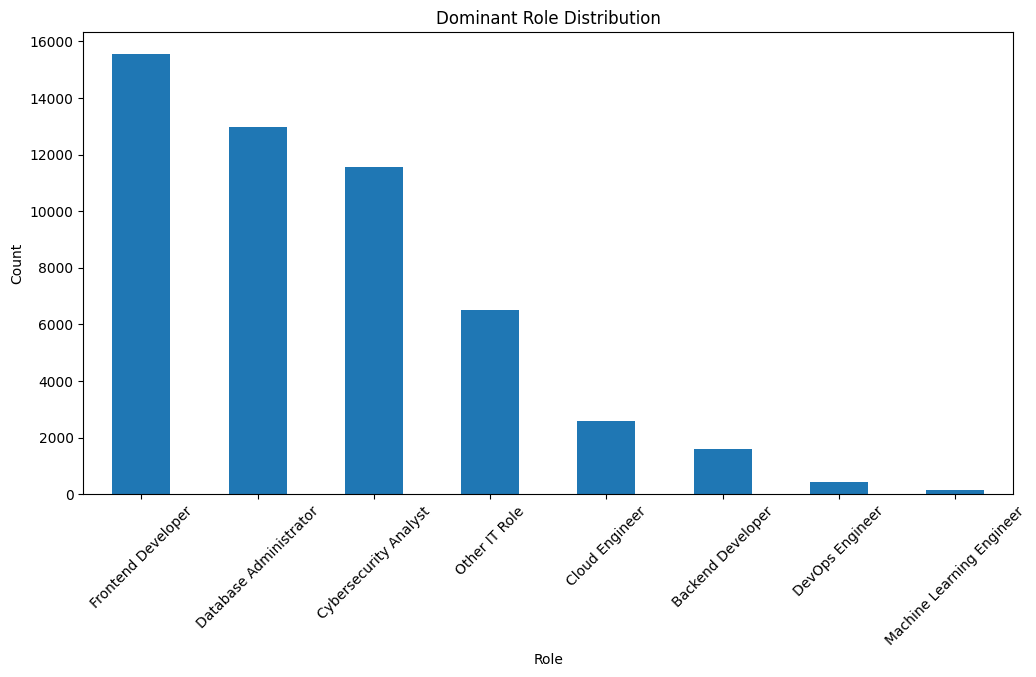

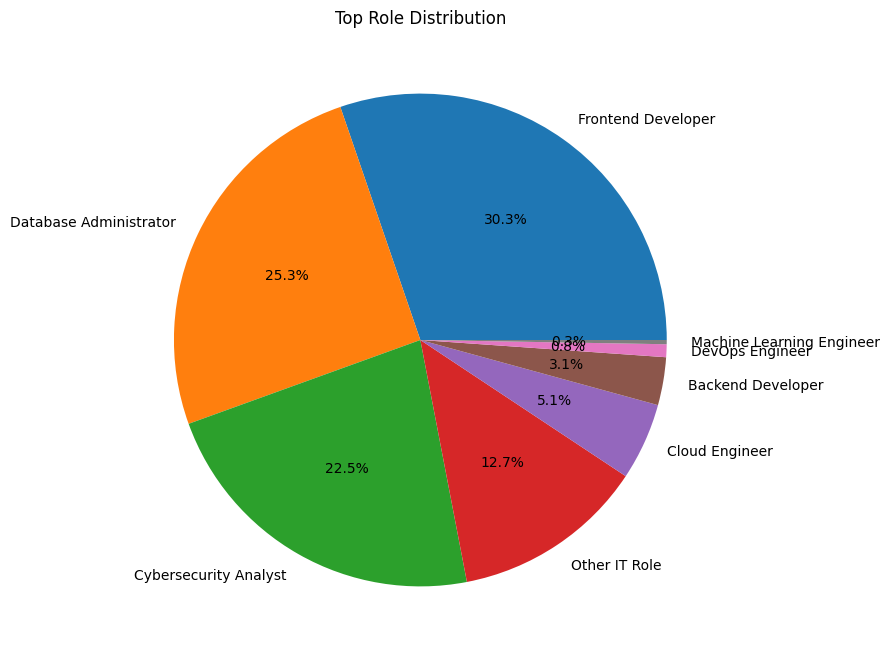

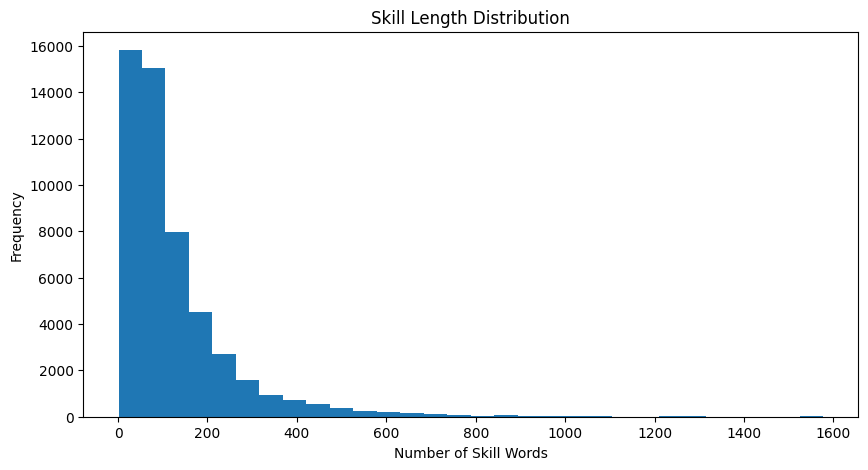


PROCESS COMPLETED SUCCESSFULLY

COMPLETED PHASES:

1. Dominant Role Detection
2. Semantic Role Intelligence
3. Project Enrichment
4. Certification Enrichment
5. Tool Enrichment
6. Technology Enrichment
7. Internship Enrichment

OUTPUT FILE:
enriched_resume_dataset.csv

NEXT PHASE:
SEMANTIC RESUME GENERATION
→ MPNet EMBEDDINGS



In [2]:
# ============================================================
# NLP PROJECT
# ROLE DETECTION + SEMANTIC ENRICHMENT
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ============================================================
# LOAD AGGREGATED DATASET
# ============================================================

input_path = "/content/drive/MyDrive/NLP_Project-2/Dataset_add/aggregated_resume_dataset.csv"

output_path = "/content/drive/MyDrive/NLP_Project-2/Dataset_add/enriched_resume_dataset.csv"

print("=" * 80)
print("LOADING AGGREGATED DATASET...")
print("=" * 80)

df = pd.read_csv(input_path)

print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

# ============================================================
# ROLE KNOWLEDGE BASE
# ============================================================

print("\n" + "=" * 80)
print("CREATING ROLE KNOWLEDGE BASE")
print("=" * 80)

ROLE_TEMPLATES = {

    "Frontend Developer": {

        "keywords": [
            "react", "javascript", "html", "css",
            "frontend", "angular", "vue", "tailwind"
        ],

        "projects": [
            "Developed responsive web applications",
            "Built admin dashboard using React",
            "Created modern UI components"
        ],

        "tools": [
            "GitHub", "VS Code", "Figma"
        ],

        "certifications": [
            "Meta Frontend Developer"
        ],

        "technologies": [
            "React", "JavaScript", "Tailwind CSS"
        ],

        "internships": [
            "Frontend Developer Intern"
        ]
    },

    "Backend Developer": {

        "keywords": [
            "node", "spring", "django",
            "backend", "express", "api"
        ],

        "projects": [
            "Built REST API systems",
            "Developed backend microservices",
            "Implemented authentication systems"
        ],

        "tools": [
            "Postman", "Git", "Docker"
        ],

        "certifications": [
            "Backend Development Certification"
        ],

        "technologies": [
            "Node.js", "Spring Boot", "MongoDB"
        ],

        "internships": [
            "Backend Developer Intern"
        ]
    },

    "Machine Learning Engineer": {

        "keywords": [
            "tensorflow", "pytorch", "nlp",
            "machine learning", "deep learning",
            "cnn", "transformers"
        ],

        "projects": [
            "Built deep learning models",
            "Developed NLP classification systems",
            "Implemented transformer architectures"
        ],

        "tools": [
            "Jupyter", "Google Colab", "MLflow"
        ],

        "certifications": [
            "TensorFlow Developer Certificate"
        ],

        "technologies": [
            "TensorFlow", "PyTorch", "Scikit-learn"
        ],

        "internships": [
            "Machine Learning Intern"
        ]
    },

    "DevOps Engineer": {

        "keywords": [
            "docker", "kubernetes",
            "jenkins", "terraform",
            "devops", "ci/cd"
        ],

        "projects": [
            "Built CI/CD pipelines",
            "Automated cloud deployment",
            "Managed containerized infrastructure"
        ],

        "tools": [
            "Docker", "Jenkins", "Kubernetes"
        ],

        "certifications": [
            "AWS DevOps Engineer"
        ],

        "technologies": [
            "Docker", "Terraform", "AWS"
        ],

        "internships": [
            "DevOps Engineer Intern"
        ]
    },

    "Cloud Engineer": {

        "keywords": [
            "aws", "azure", "gcp",
            "cloud", "lambda"
        ],

        "projects": [
            "Deployed scalable cloud systems",
            "Managed cloud infrastructure",
            "Implemented serverless applications"
        ],

        "tools": [
            "AWS Console", "Terraform"
        ],

        "certifications": [
            "AWS Solutions Architect"
        ],

        "technologies": [
            "AWS", "Azure", "GCP"
        ],

        "internships": [
            "Cloud Engineer Intern"
        ]
    },

    "Cybersecurity Analyst": {

        "keywords": [
            "security", "cyber",
            "penetration", "siem",
            "wireshark", "kali"
        ],

        "projects": [
            "Performed vulnerability assessment",
            "Conducted penetration testing",
            "Implemented network security systems"
        ],

        "tools": [
            "Wireshark", "Metasploit", "Burp Suite"
        ],

        "certifications": [
            "Certified Ethical Hacker"
        ],

        "technologies": [
            "SIEM", "Firewalls", "Kali Linux"
        ],

        "internships": [
            "Cybersecurity Intern"
        ]
    },

    "Database Administrator": {

        "keywords": [
            "sql", "oracle",
            "database", "dba",
            "mysql", "postgresql"
        ],

        "projects": [
            "Managed enterprise databases",
            "Optimized SQL queries",
            "Implemented database backup systems"
        ],

        "tools": [
            "Oracle DB", "SQL Server"
        ],

        "certifications": [
            "Oracle Database Certification"
        ],

        "technologies": [
            "SQL", "Oracle", "MySQL"
        ],

        "internships": [
            "Database Administrator Intern"
        ]
    }
}

# ============================================================
# ROLE DETECTION FUNCTION
# ============================================================

print("\n" + "=" * 80)
print("DETECTING DOMINANT ROLES")
print("=" * 80)

def detect_role(row):

    text = " ".join([

        str(row['profile_title']),
        str(row['all_skills']),
        str(row['all_abilities']),
        str(row['all_experience_titles'])

    ]).lower()

    role_scores = {}

    for role, data in ROLE_TEMPLATES.items():

        score = 0

        for keyword in data['keywords']:

            if keyword.lower() in text:
                score += 1

        role_scores[role] = score

    dominant_role = max(role_scores, key=role_scores.get)

    if role_scores[dominant_role] == 0:
        return "Other IT Role"

    return dominant_role

df['dominant_role'] = df.apply(detect_role, axis=1)

print("Role Detection Completed.")

# ============================================================
# ROLE DISTRIBUTION
# ============================================================

print("\nROLE DISTRIBUTION")
print("=" * 80)

print(df['dominant_role'].value_counts())

# ============================================================
# ENRICHMENT FUNCTIONS
# ============================================================

print("\n" + "=" * 80)
print("STARTING SEMANTIC ENRICHMENT")
print("=" * 80)

def enrich_projects(role):

    if role in ROLE_TEMPLATES:
        return " | ".join(
            ROLE_TEMPLATES[role]['projects']
        )

    return ""

def enrich_tools(role):

    if role in ROLE_TEMPLATES:
        return " | ".join(
            ROLE_TEMPLATES[role]['tools']
        )

    return ""

def enrich_certifications(role):

    if role in ROLE_TEMPLATES:
        return " | ".join(
            ROLE_TEMPLATES[role]['certifications']
        )

    return ""

def enrich_technologies(role):

    if role in ROLE_TEMPLATES:
        return " | ".join(
            ROLE_TEMPLATES[role]['technologies']
        )

    return ""

def enrich_internships(role):

    if role in ROLE_TEMPLATES:
        return " | ".join(
            ROLE_TEMPLATES[role]['internships']
        )

    return ""

# ============================================================
# APPLY ENRICHMENT
# ============================================================

df['projects'] = df['dominant_role'].apply(
    enrich_projects
)

df['tools'] = df['dominant_role'].apply(
    enrich_tools
)

df['certifications'] = df['dominant_role'].apply(
    enrich_certifications
)

df['technologies'] = df['dominant_role'].apply(
    enrich_technologies
)

df['internships'] = df['dominant_role'].apply(
    enrich_internships
)

print("Semantic Enrichment Completed.")

# ============================================================
# FINAL DATASET ANALYSIS
# ============================================================

print("\nFINAL ENRICHED DATASET")
print("=" * 80)

print("Final Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSample Enriched Data:")
print(df.head())

# ============================================================
# SAVE DATASET
# ============================================================

print("\nSAVING ENRICHED DATASET...")
print("=" * 80)

df.to_csv(output_path, index=False)

print(f"Saved Successfully:")
print(output_path)

# ============================================================
# VISUALIZATIONS
# ============================================================

print("\nGENERATING VISUALIZATIONS...")
print("=" * 80)

# ------------------------------------------------------------
# ROLE DISTRIBUTION
# ------------------------------------------------------------

role_counts = df['dominant_role'].value_counts()

plt.figure(figsize=(12, 6))

role_counts.plot(kind='bar')

plt.title("Dominant Role Distribution")
plt.xlabel("Role")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ------------------------------------------------------------
# TOP ROLES PIE CHART
# ------------------------------------------------------------

top_roles = df['dominant_role'].value_counts().head(8)

plt.figure(figsize=(8, 8))

top_roles.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Top Role Distribution")
plt.ylabel("")

plt.show()

# ------------------------------------------------------------
# SKILL LENGTH DISTRIBUTION
# ------------------------------------------------------------

df['skill_length'] = df['all_skills'].apply(
    lambda x: len(str(x).split())
)

plt.figure(figsize=(10, 5))

plt.hist(df['skill_length'], bins=30)

plt.title("Skill Length Distribution")
plt.xlabel("Number of Skill Words")
plt.ylabel("Frequency")

plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("PROCESS COMPLETED SUCCESSFULLY")
print("=" * 80)

print("""
COMPLETED PHASES:

1. Dominant Role Detection
2. Semantic Role Intelligence
3. Project Enrichment
4. Certification Enrichment
5. Tool Enrichment
6. Technology Enrichment
7. Internship Enrichment

OUTPUT FILE:
enriched_resume_dataset.csv

NEXT PHASE:
SEMANTIC RESUME GENERATION
→ MPNet EMBEDDINGS
""")

LOADING ENRICHED DATASET...

Initial Shape: (51378, 16)

INITIAL ROLE DISTRIBUTION
dominant_role
Frontend Developer           15549
Database Administrator       12978
Cybersecurity Analyst        11562
Other IT Role                 6501
Cloud Engineer                2601
Backend Developer             1614
DevOps Engineer                432
Machine Learning Engineer      141
Name: count, dtype: int64

REMOVING GENERIC ROLES...
Rows Removed: 6501

SETTING TARGET SAMPLE SIZE...
Target Samples Per Role: 3000

Filtered Dataset Shape: (44877, 16)

STARTING ROLE BALANCING

Role: Frontend Developer
Current Size: 15549
Downsampled to: 3000

Role: Backend Developer
Current Size: 1614
Upsampled to: 3000

Role: Machine Learning Engineer
Current Size: 141
Upsampled to: 3000

Role: DevOps Engineer
Current Size: 432
Upsampled to: 3000

Role: Cloud Engineer
Current Size: 2601
Upsampled to: 3000

Role: Cybersecurity Analyst
Current Size: 11562
Downsampled to: 3000

Role: Database Administrator
Current 

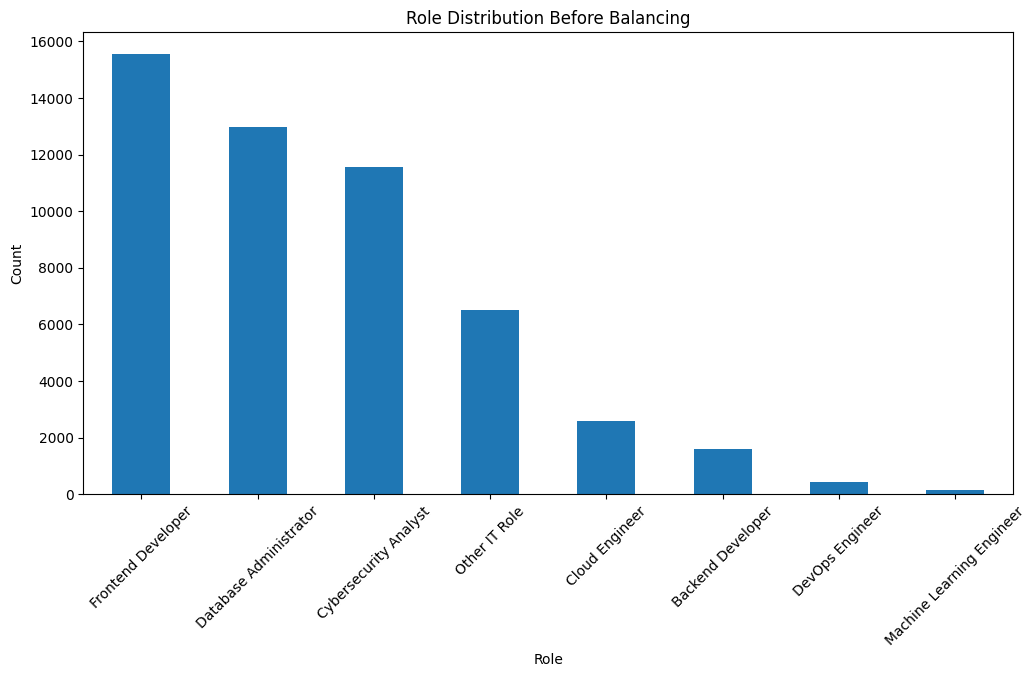

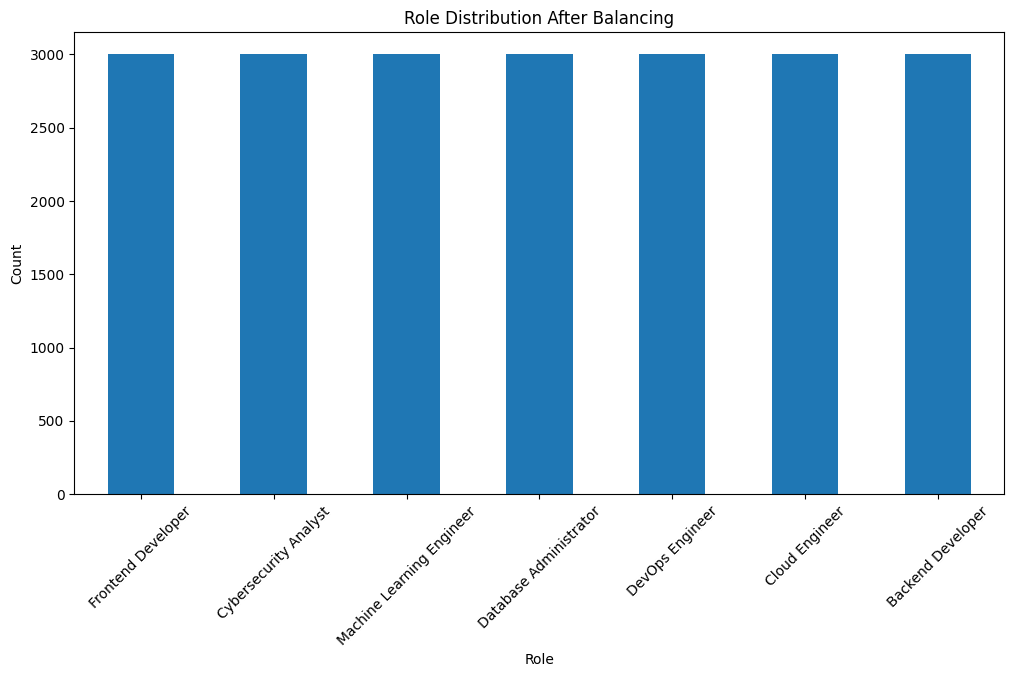

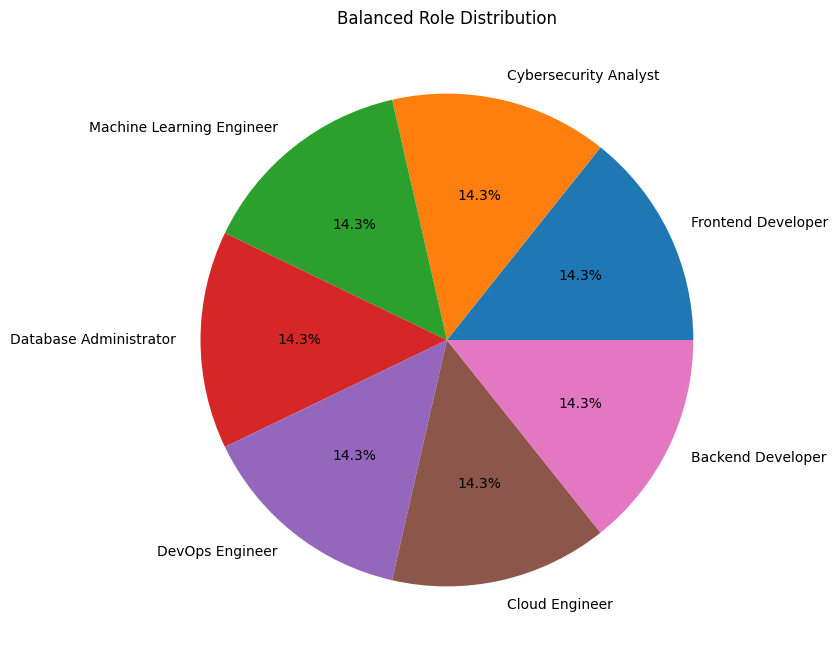

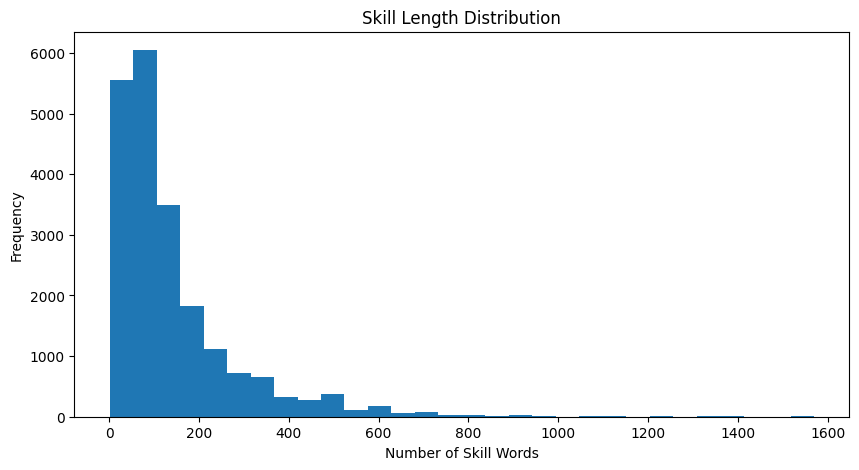


PROCESS COMPLETED SUCCESSFULLY

COMPLETED:

1. Removed Generic Roles
2. Filtered Target IT Roles
3. Balanced Dataset Using Resampling
4. Created Equal Semantic Role Distribution
5. Generated Analysis Plots

FINAL OUTPUT:
balanced_resume_dataset.csv

NEXT STEP:
SEMANTIC RESUME GENERATION
(FINAL NLP INPUT BEFORE MPNet)



In [3]:
# ============================================================
# NLP PROJECT
# ROLE BALANCING + DATA AUGMENTATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import resample

# ============================================================
# LOAD ENRICHED DATASET
# ============================================================

input_path = "/content/drive/MyDrive/NLP_Project-2/Dataset_add/enriched_resume_dataset.csv"

output_path = "/content/drive/MyDrive/NLP_Project-2/Dataset_add/balanced_resume_dataset.csv"

print("=" * 80)
print("LOADING ENRICHED DATASET...")
print("=" * 80)

df = pd.read_csv(input_path)

print("\nInitial Shape:", df.shape)

# ============================================================
# INITIAL ROLE DISTRIBUTION
# ============================================================

print("\nINITIAL ROLE DISTRIBUTION")
print("=" * 80)

initial_distribution = df['dominant_role'].value_counts()

print(initial_distribution)

# ============================================================
# REMOVE WEAK / GENERIC ROLES
# ============================================================

print("\nREMOVING GENERIC ROLES...")
print("=" * 80)

before_remove = df.shape[0]

df = df[df['dominant_role'] != 'Other IT Role']

after_remove = df.shape[0]

print(f"Rows Removed: {before_remove - after_remove}")

# ============================================================
# TARGET BALANCED SAMPLE SIZE
# ============================================================

print("\nSETTING TARGET SAMPLE SIZE...")
print("=" * 80)

TARGET_SIZE = 3000

print(f"Target Samples Per Role: {TARGET_SIZE}")

# ============================================================
# FINAL TARGET ROLES
# ============================================================

TARGET_ROLES = [

    "Frontend Developer",
    "Backend Developer",
    "Machine Learning Engineer",
    "DevOps Engineer",
    "Cloud Engineer",
    "Cybersecurity Analyst",
    "Database Administrator"

]

# ============================================================
# FILTER ONLY TARGET ROLES
# ============================================================

df = df[df['dominant_role'].isin(TARGET_ROLES)]

print("\nFiltered Dataset Shape:", df.shape)

# ============================================================
# BALANCING PROCESS
# ============================================================

print("\n" + "=" * 80)
print("STARTING ROLE BALANCING")
print("=" * 80)

balanced_dfs = []

for role in TARGET_ROLES:

    role_df = df[df['dominant_role'] == role]

    current_size = role_df.shape[0]

    print(f"\nRole: {role}")
    print(f"Current Size: {current_size}")

    # --------------------------------------------------------
    # UPSAMPLING
    # --------------------------------------------------------

    if current_size < TARGET_SIZE:

        upsampled = resample(

            role_df,

            replace=True,
            n_samples=TARGET_SIZE,
            random_state=42

        )

        balanced_dfs.append(upsampled)

        print(f"Upsampled to: {TARGET_SIZE}")

    # --------------------------------------------------------
    # DOWNSAMPLING
    # --------------------------------------------------------

    elif current_size > TARGET_SIZE:

        downsampled = resample(

            role_df,

            replace=False,
            n_samples=TARGET_SIZE,
            random_state=42

        )

        balanced_dfs.append(downsampled)

        print(f"Downsampled to: {TARGET_SIZE}")

    # --------------------------------------------------------
    # ALREADY BALANCED
    # --------------------------------------------------------

    else:

        balanced_dfs.append(role_df)

        print("Already Balanced")

# ============================================================
# COMBINE BALANCED DATA
# ============================================================

print("\nCOMBINING BALANCED DATASETS...")
print("=" * 80)

balanced_df = pd.concat(balanced_dfs)

# ============================================================
# SHUFFLE DATASET
# ============================================================

balanced_df = balanced_df.sample(

    frac=1,
    random_state=42

).reset_index(drop=True)

# ============================================================
# FINAL DATASET ANALYSIS
# ============================================================

print("\nFINAL BALANCED DATASET")
print("=" * 80)

print("Final Shape:", balanced_df.shape)

print("\nFinal Role Distribution:")
print(balanced_df['dominant_role'].value_counts())

print("\nColumns:")
print(balanced_df.columns.tolist())

print("\nMissing Values:")
print(balanced_df.isnull().sum())

print("\nSample Data:")
print(balanced_df.head())

# ============================================================
# SAVE BALANCED DATASET
# ============================================================

print("\nSAVING BALANCED DATASET...")
print("=" * 80)

balanced_df.to_csv(output_path, index=False)

print(f"Saved Successfully:")
print(output_path)

# ============================================================
# VISUALIZATIONS
# ============================================================

print("\nGENERATING VISUALIZATIONS...")
print("=" * 80)

# ------------------------------------------------------------
# BEFORE BALANCING
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

initial_distribution.plot(kind='bar')

plt.title("Role Distribution Before Balancing")
plt.xlabel("Role")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ------------------------------------------------------------
# AFTER BALANCING
# ------------------------------------------------------------

final_distribution = balanced_df[
    'dominant_role'
].value_counts()

plt.figure(figsize=(12, 6))

final_distribution.plot(kind='bar')

plt.title("Role Distribution After Balancing")
plt.xlabel("Role")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ------------------------------------------------------------
# PIE CHART
# ------------------------------------------------------------

plt.figure(figsize=(8, 8))

final_distribution.plot(

    kind='pie',
    autopct='%1.1f%%'

)

plt.title("Balanced Role Distribution")
plt.ylabel("")

plt.show()

# ------------------------------------------------------------
# SKILL LENGTH DISTRIBUTION
# ------------------------------------------------------------

balanced_df['skill_length'] = balanced_df[
    'all_skills'
].apply(

    lambda x: len(str(x).split())

)

plt.figure(figsize=(10, 5))

plt.hist(

    balanced_df['skill_length'],
    bins=30

)

plt.title("Skill Length Distribution")
plt.xlabel("Number of Skill Words")
plt.ylabel("Frequency")

plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("PROCESS COMPLETED SUCCESSFULLY")
print("=" * 80)

print("""
COMPLETED:

1. Removed Generic Roles
2. Filtered Target IT Roles
3. Balanced Dataset Using Resampling
4. Created Equal Semantic Role Distribution
5. Generated Analysis Plots

FINAL OUTPUT:
balanced_resume_dataset.csv

NEXT STEP:
SEMANTIC RESUME GENERATION
(FINAL NLP INPUT BEFORE MPNet)
""")

LOADING BALANCED DATASET...

Dataset Shape: (21000, 16)

Columns:
['person_id', 'profile_title', 'standardized_role', 'all_abilities', 'all_institutions', 'all_education', 'all_experience_titles', 'all_companies', 'experience_roles', 'all_skills', 'dominant_role', 'projects', 'tools', 'certifications', 'technologies', 'internships']

FILLING NULL VALUES...
Null Values Filled.

CREATING HELPER FUNCTIONS...

GENERATING SEMANTIC RESUMES...
Semantic Resume Generation Completed.

SEMANTIC RESUME ANALYSIS

Resume Word Count Statistics:
count    21000.000000
mean       323.501476
std        218.289648
min         62.000000
25%        189.000000
50%        256.000000
75%        380.000000
max       2106.000000
Name: resume_word_count, dtype: float64

SAMPLE SEMANTIC RESUMES

Sample Resume 1
--------------------------------------------------------------------------------
Professional Frontend Developer experienced in webpack , react js , ajax , gulp and grunt , user science testing and accessib

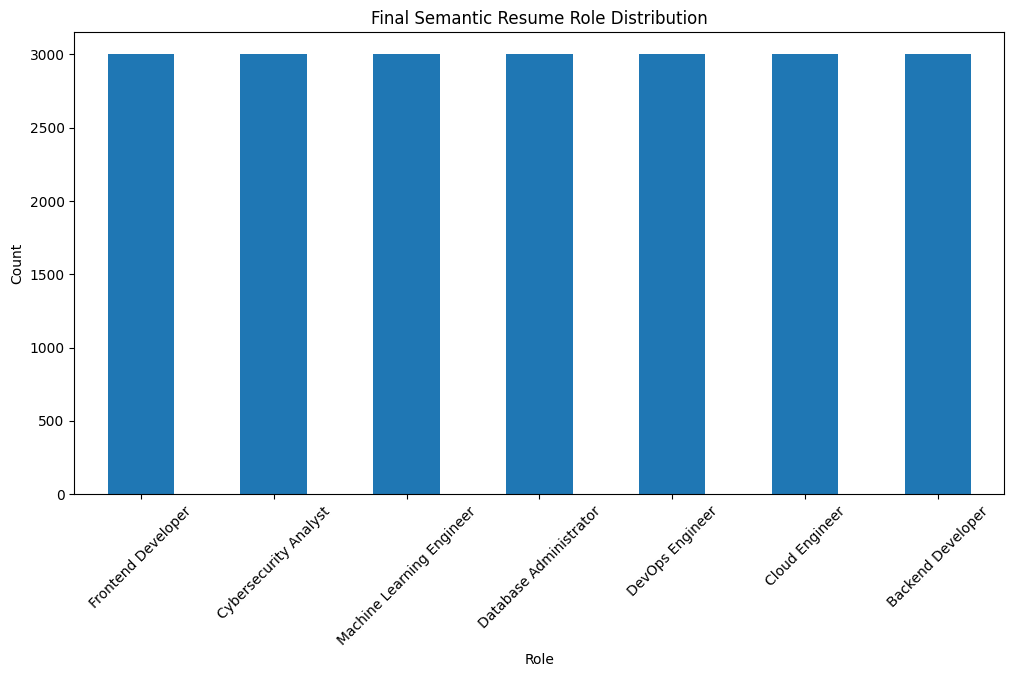

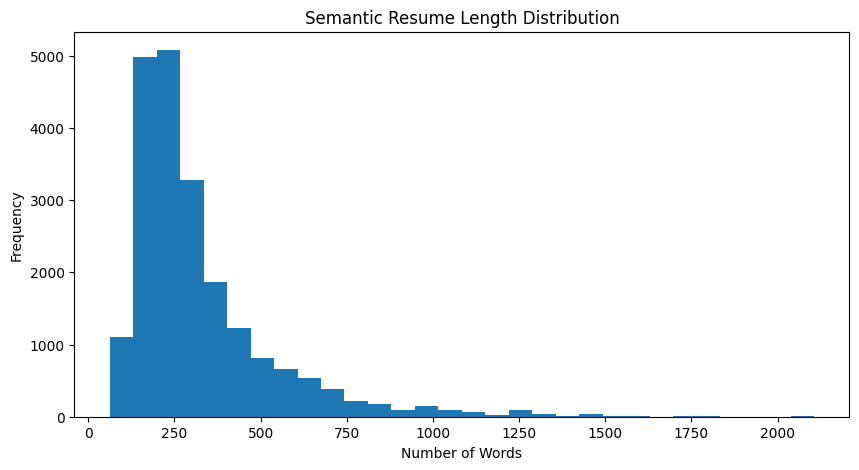

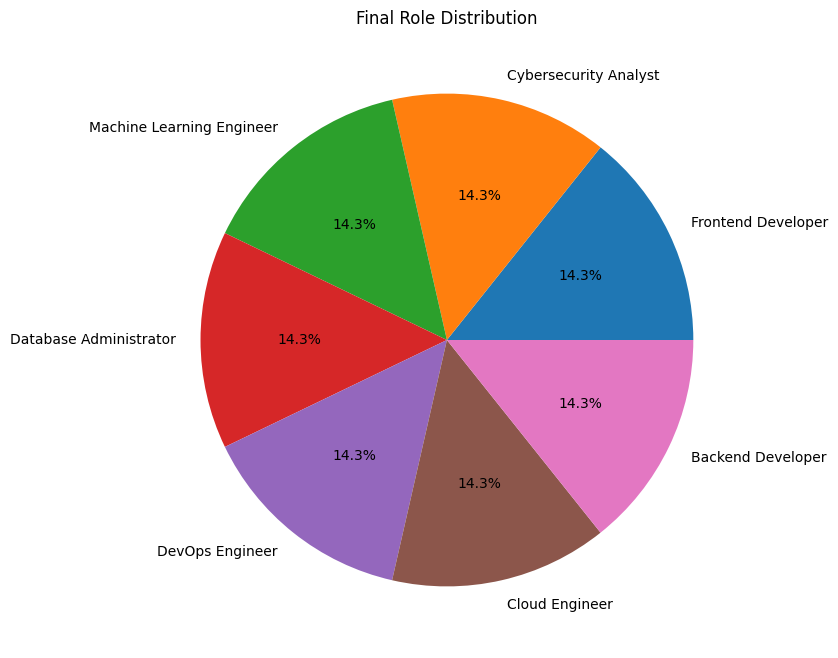

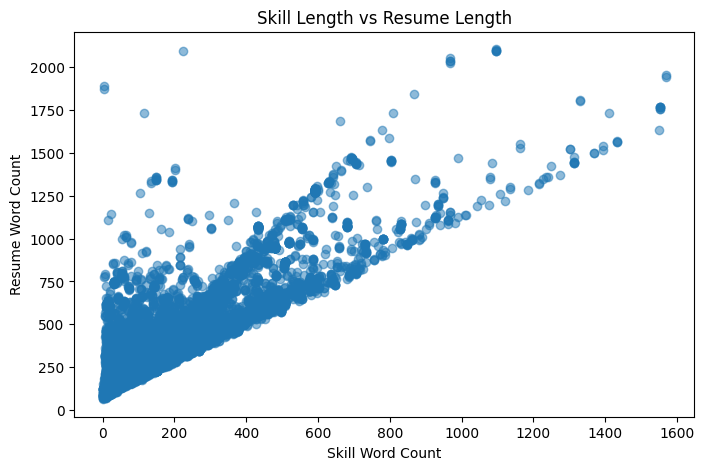


PROCESS COMPLETED SUCCESSFULLY

COMPLETED FINAL NLP DATASET GENERATION

FINAL PIPELINE COMPLETED:

1. Data Cleaning
2. Aggregation
3. Role Detection
4. Semantic Enrichment
5. Role Balancing
6. Semantic Resume Generation

FINAL OUTPUT:
final_semantic_resume_dataset.csv

MOST IMPORTANT COLUMN:
semantic_resume

THIS COLUMN WILL NOW BE USED FOR:

→ MPNet Embeddings
→ Semantic Similarity
→ KMeans Clustering
→ Recommendation Engine
→ Skill Gap Analysis

NEXT STEP:
MPNet EMBEDDING GENERATION



In [4]:
# ============================================================
# NLP PROJECT
# FINAL SEMANTIC RESUME GENERATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# ============================================================
# LOAD BALANCED DATASET
# ============================================================

input_path = "/content/drive/MyDrive/NLP_Project-2/Dataset_add/balanced_resume_dataset.csv"

output_path = "/content/drive/MyDrive/NLP_Project-2/Dataset_add/final_semantic_resume_dataset.csv"

print("=" * 80)
print("LOADING BALANCED DATASET...")
print("=" * 80)

df = pd.read_csv(input_path)

print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

# ============================================================
# FILL NULL VALUES
# ============================================================

print("\nFILLING NULL VALUES...")
print("=" * 80)

text_columns = [

    'profile_title',
    'all_abilities',
    'all_institutions',
    'all_education',
    'all_experience_titles',
    'all_companies',
    'all_skills',
    'projects',
    'tools',
    'certifications',
    'technologies',
    'internships'

]

for col in text_columns:

    df[col] = df[col].fillna("")

print("Null Values Filled.")

# ============================================================
# HELPER FUNCTIONS
# ============================================================

print("\nCREATING HELPER FUNCTIONS...")
print("=" * 80)

def clean_text(text):

    if pd.isnull(text):
        return ""

    text = str(text)

    text = text.replace("|", ", ")

    text = text.replace("  ", " ")

    return text.strip()

# ============================================================
# SEMANTIC RESUME GENERATOR
# ============================================================

print("\nGENERATING SEMANTIC RESUMES...")
print("=" * 80)

def generate_semantic_resume(row):

    role = clean_text(row['dominant_role'])

    skills = clean_text(row['all_skills'])

    abilities = clean_text(row['all_abilities'])

    education = clean_text(row['all_education'])

    institutions = clean_text(row['all_institutions'])

    experience = clean_text(row['all_experience_titles'])

    companies = clean_text(row['all_companies'])

    projects = clean_text(row['projects'])

    tools = clean_text(row['tools'])

    certifications = clean_text(row['certifications'])

    technologies = clean_text(row['technologies'])

    internships = clean_text(row['internships'])

    # --------------------------------------------------------
    # SEMANTIC SENTENCES
    # --------------------------------------------------------

    intro_templates = [

        f"{role} skilled in {skills}.",

        f"Experienced {role} with expertise in {skills}.",

        f"{role} specializing in {skills}.",

        f"Professional {role} experienced in {skills}."

    ]

    ability_templates = [

        f"Strong abilities in {abilities}.",

        f"Demonstrated expertise in {abilities}.",

        f"Experienced with {abilities}.",

        f"Hands-on experience in {abilities}."

    ]

    experience_templates = [

        f"Worked as {experience}.",

        f"Professional experience includes {experience}.",

        f"Industry experience in {experience}.",

        f"Worked with organizations such as {companies}."

    ]

    project_templates = [

        f"Projects include {projects}.",

        f"Developed systems such as {projects}.",

        f"Built real-world applications including {projects}.",

        f"Implemented industry projects like {projects}."

    ]

    technology_templates = [

        f"Experienced with technologies including {technologies}.",

        f"Worked extensively with {technologies}.",

        f"Technical stack includes {technologies}.",

        f"Hands-on exposure to {technologies}."
    ]

    tool_templates = [

        f"Skilled in tools such as {tools}.",

        f"Experienced using {tools}.",

        f"Worked with development tools including {tools}.",

        f"Utilized professional tools like {tools}."
    ]

    education_templates = [

        f"Educational background in {education}.",

        f"Completed studies in {education}.",

        f"Academic specialization in {education}.",

        f"Studied at {institutions} with focus on {education}."
    ]

    certification_templates = [

        f"Certified in {certifications}.",

        f"Completed certifications including {certifications}.",

        f"Holds certifications such as {certifications}.",

        f"Professional certifications include {certifications}."
    ]

    internship_templates = [

        f"Completed internship as {internships}.",

        f"Industry internship experience as {internships}.",

        f"Worked in internship roles such as {internships}.",

        f"Gained practical experience through {internships}."
    ]

    # --------------------------------------------------------
    # BUILD SEMANTIC PROFILE
    # --------------------------------------------------------

    semantic_resume = " ".join([

        random.choice(intro_templates),

        random.choice(ability_templates),

        random.choice(experience_templates),

        random.choice(project_templates),

        random.choice(technology_templates),

        random.choice(tool_templates),

        random.choice(education_templates),

        random.choice(certification_templates),

        random.choice(internship_templates)

    ])

    return semantic_resume

# ============================================================
# APPLY SEMANTIC RESUME GENERATION
# ============================================================

df['semantic_resume'] = df.apply(

    generate_semantic_resume,
    axis=1

)

print("Semantic Resume Generation Completed.")

# ============================================================
# SEMANTIC RESUME ANALYSIS
# ============================================================

print("\nSEMANTIC RESUME ANALYSIS")
print("=" * 80)

# ------------------------------------------------------------
# WORD COUNT
# ------------------------------------------------------------

df['resume_word_count'] = df['semantic_resume'].apply(

    lambda x: len(str(x).split())

)

print("\nResume Word Count Statistics:")

print(df['resume_word_count'].describe())

# ============================================================
# SAMPLE SEMANTIC RESUMES
# ============================================================

print("\nSAMPLE SEMANTIC RESUMES")
print("=" * 80)

for i in range(3):

    print(f"\nSample Resume {i+1}")
    print("-" * 80)

    print(df['semantic_resume'].iloc[i])

# ============================================================
# FINAL DATASET STRUCTURE
# ============================================================

print("\nFINAL DATASET INFORMATION")
print("=" * 80)

print("Final Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================================
# SAVE FINAL DATASET
# ============================================================

print("\nSAVING FINAL SEMANTIC RESUME DATASET...")
print("=" * 80)

df.to_csv(output_path, index=False)

print(f"Saved Successfully:")
print(output_path)

# ============================================================
# VISUALIZATIONS
# ============================================================

print("\nGENERATING VISUALIZATIONS...")
print("=" * 80)

# ------------------------------------------------------------
# ROLE DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

df['dominant_role'].value_counts().plot(kind='bar')

plt.title("Final Semantic Resume Role Distribution")
plt.xlabel("Role")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ------------------------------------------------------------
# RESUME LENGTH DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.hist(

    df['resume_word_count'],
    bins=30

)

plt.title("Semantic Resume Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

# ------------------------------------------------------------
# PIE CHART
# ------------------------------------------------------------

plt.figure(figsize=(8, 8))

df['dominant_role'].value_counts().plot(

    kind='pie',
    autopct='%1.1f%%'

)

plt.title("Final Role Distribution")
plt.ylabel("")

plt.show()

# ------------------------------------------------------------
# SKILL LENGTH VS RESUME LENGTH
# ------------------------------------------------------------

df['skill_word_count'] = df['all_skills'].apply(

    lambda x: len(str(x).split())

)

plt.figure(figsize=(8, 5))

plt.scatter(

    df['skill_word_count'],
    df['resume_word_count'],
    alpha=0.5

)

plt.title("Skill Length vs Resume Length")
plt.xlabel("Skill Word Count")
plt.ylabel("Resume Word Count")

plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("PROCESS COMPLETED SUCCESSFULLY")
print("=" * 80)

print("""
COMPLETED FINAL NLP DATASET GENERATION

FINAL PIPELINE COMPLETED:

1. Data Cleaning
2. Aggregation
3. Role Detection
4. Semantic Enrichment
5. Role Balancing
6. Semantic Resume Generation

FINAL OUTPUT:
final_semantic_resume_dataset.csv

MOST IMPORTANT COLUMN:
semantic_resume

THIS COLUMN WILL NOW BE USED FOR:

→ MPNet Embeddings
→ Semantic Similarity
→ KMeans Clustering
→ Recommendation Engine
→ Skill Gap Analysis

NEXT STEP:
MPNet EMBEDDING GENERATION
""")